In [2]:
import os
import time
import importlib
import nest_asyncio
import featureExtractor as ext

# 주피터 노트북에서 이벤트 루프 재진입을 가능하게 함
nest_asyncio.apply()

importlib.reload(ext)

# 폴더 선택 다이얼로그 표시
selected_directory = "./FSD50K.eval_audio"
if not selected_directory:
    print("Folder selection cancelled.")
else:
    # 현재 시간 가져오기
    current_time = time.strftime("%Y%m%d-%H%M%S")

    # 선택한 폴더명 추출
    folder_name = os.path.basename(os.path.normpath(selected_directory))
    file_name = f"{folder_name}"
    print(f"Processing folder: {selected_directory}")
    print(f"Generated file name: {file_name}")

    # 오디오 파일 읽어서 buffers 생성
    buffers = ext.readfile(selected_directory, file_name, detect_onset=True)

Processing folder: ./FSD50K.eval_audio
Generated file name: FSD50K.eval_audio
Loaded 5240 buffers from FSD50K.eval_audio.pkl.
readfile 처리 시간: 0.10초


In [ ]:
import asyncio

# 비동기식 feature 추출 실행
asyncio.run(ext.async_featureExtract(file_name))

In [5]:
import pickle

features_pkl_path = './FSD50k.eval_audiofeatures_.pkl'

try:
    with open(features_pkl_path, 'rb') as f:
        features = pickle.load(f)
except FileNotFoundError:
    print(f"파일을 찾을 수 없습니다: {features_pkl_path}")
    exit()

print(f"총 오디오 유닛 개수: {len(features)}\n")

if features and isinstance(features, list) and isinstance(features[0], dict):
    first_feature = features[0]
    print("첫번째 오디오 유닛의 메타데이터 구조:")
    for key, value in first_feature.items():
        print(f"  {key}: {value}")
else:
    print("불러온 데이터의 구조가 예상과 다릅니다.")

총 오디오 유닛 개수: 5240

첫번째 오디오 유닛의 메타데이터 구조:
  filename: 329109_onset_2.wav
  mfccs_mean: [-391.63140869140625, -49.939453125, -57.88106155395508, -13.211915969848633, -7.423596382141113, -33.947261810302734, -33.38848114013672, -53.4210205078125, -14.58215045928955, 1.6833771467208862, -19.221906661987305, 21.552000045776367, 46.754207611083984]
  spectral_centroid_mean: 2630.5380469364222
  chroma_mean: [0.23527498543262482, 0.16439425945281982, 0.09276166558265686, 0.08324644714593887, 0.195699080824852, 0.05410652235150337, 0.2567603886127472, 0.9959468245506287, 0.36742547154426575, 0.04974239319562912, 0.086613729596138, 0.16928508877754211]


Spectral Centroid (Graph)

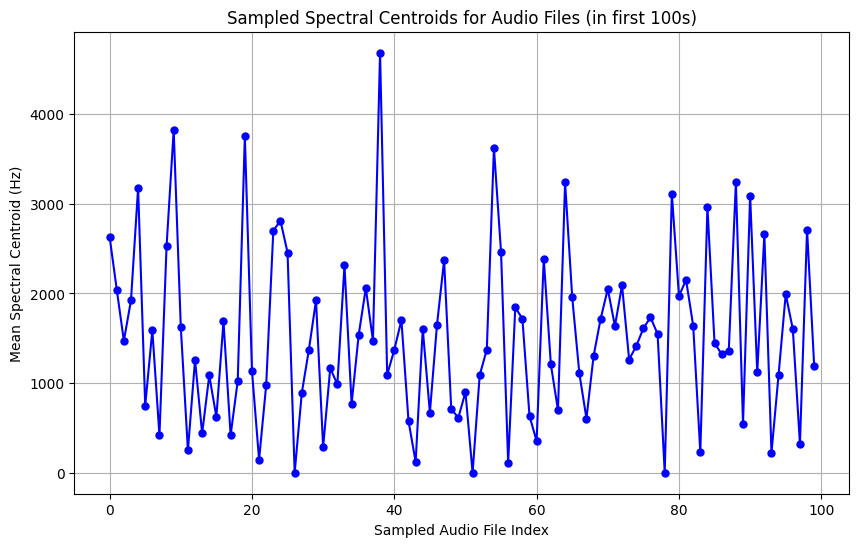

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

try:
    with open(features_pkl_path, 'rb') as f:
        features_list = pickle.load(f)
except FileNotFoundError:
    print(f"File {features_pkl_path} not found.")
    features_list = []

# Extract the spectral centroid values from the features list
centroids_list = []
for feature_data in features_list:
    spectral_centroid_mean = feature_data.get('spectral_centroid_mean')
    if spectral_centroid_mean is not None:
        centroids_list.append(spectral_centroid_mean)

# Check if there are any valid centroids to plot
if not centroids_list:
    print("No valid audio files found or processed.")
else:
    # Convert the list of spectral centroids to a NumPy array
    centroids_array = np.array(centroids_list).reshape(-1, 1)

    # Optional: Reduce the number of data points by sampling
    sample_size = min(100, len(centroids_array))  # Limit to 100 samples
    indices = np.linspace(0, len(centroids_array) - 1, sample_size).astype(int)
    sampled_centroids = centroids_array[indices]

    # Plotting the sampled spectral centroids
    plt.figure(figsize=(10, 6))
    plt.plot(sampled_centroids, marker='o', linestyle='-', color='b', markersize=5)
    plt.title('Sampled Spectral Centroids for Audio Files (in first 100s)')
    plt.xlabel('Sampled Audio File Index')
    plt.ylabel('Mean Spectral Centroid (Hz)')
    plt.grid(True)
    plt.show()


t-SNE'd MFCC Data

Extracting descriptors: 100%|██████████| 5240/5240 [00:00<00:00, 380666.36it/s]


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5077 samples in 0.000s...
[t-SNE] Computed neighbors for 5077 samples in 0.086s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5077
[t-SNE] Computed conditional probabilities for sample 2000 / 5077
[t-SNE] Computed conditional probabilities for sample 3000 / 5077
[t-SNE] Computed conditional probabilities for sample 4000 / 5077
[t-SNE] Computed conditional probabilities for sample 5000 / 5077
[t-SNE] Computed conditional probabilities for sample 5077 / 5077
[t-SNE] Mean sigma: 46.183832
[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.173798
[t-SNE] KL divergence after 1000 iterations: 0.627489


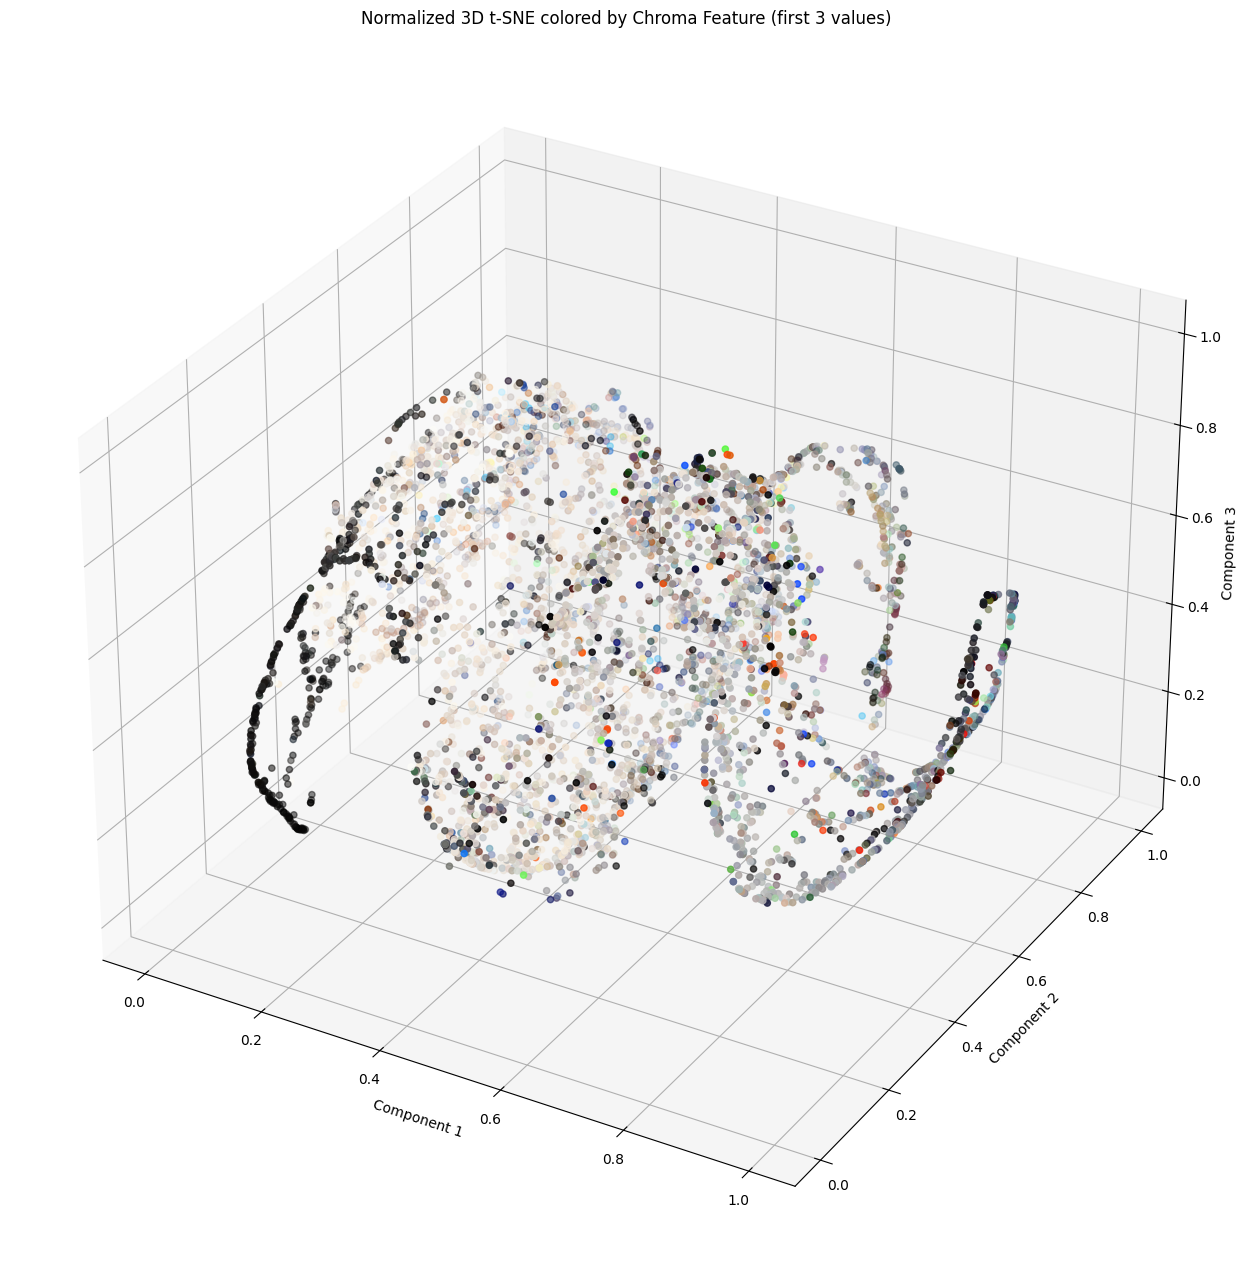

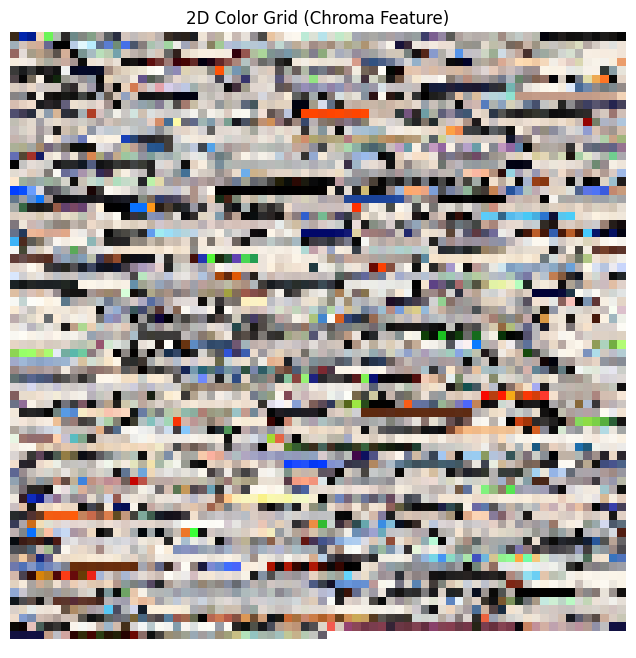

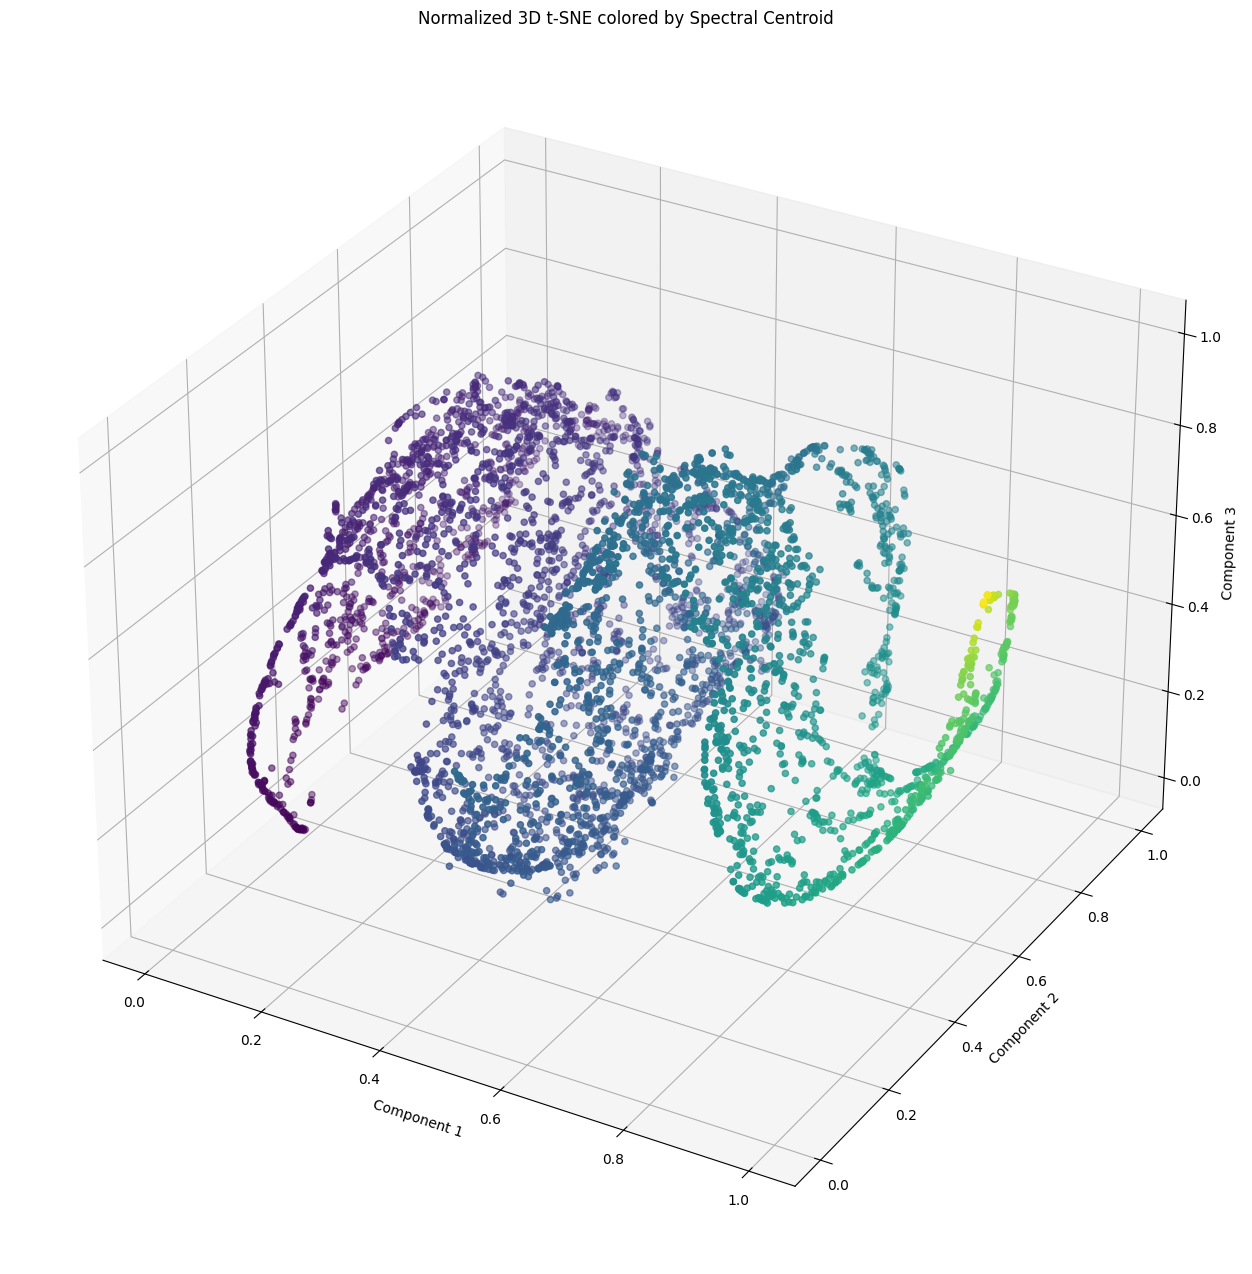

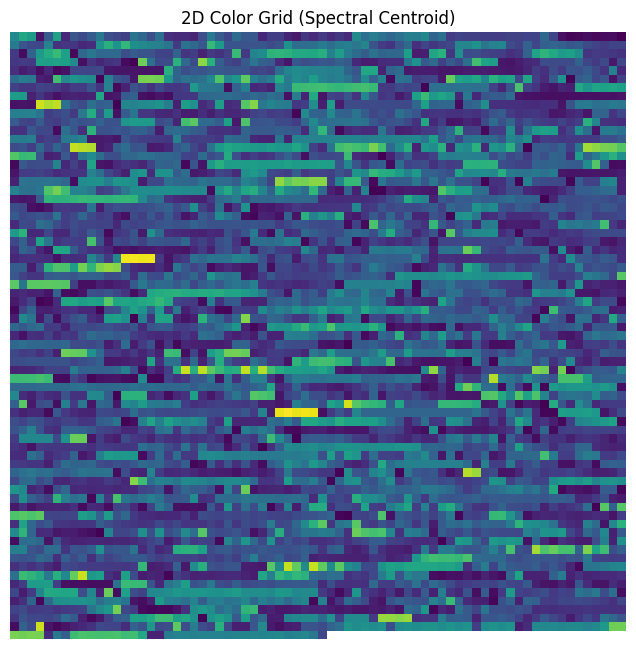

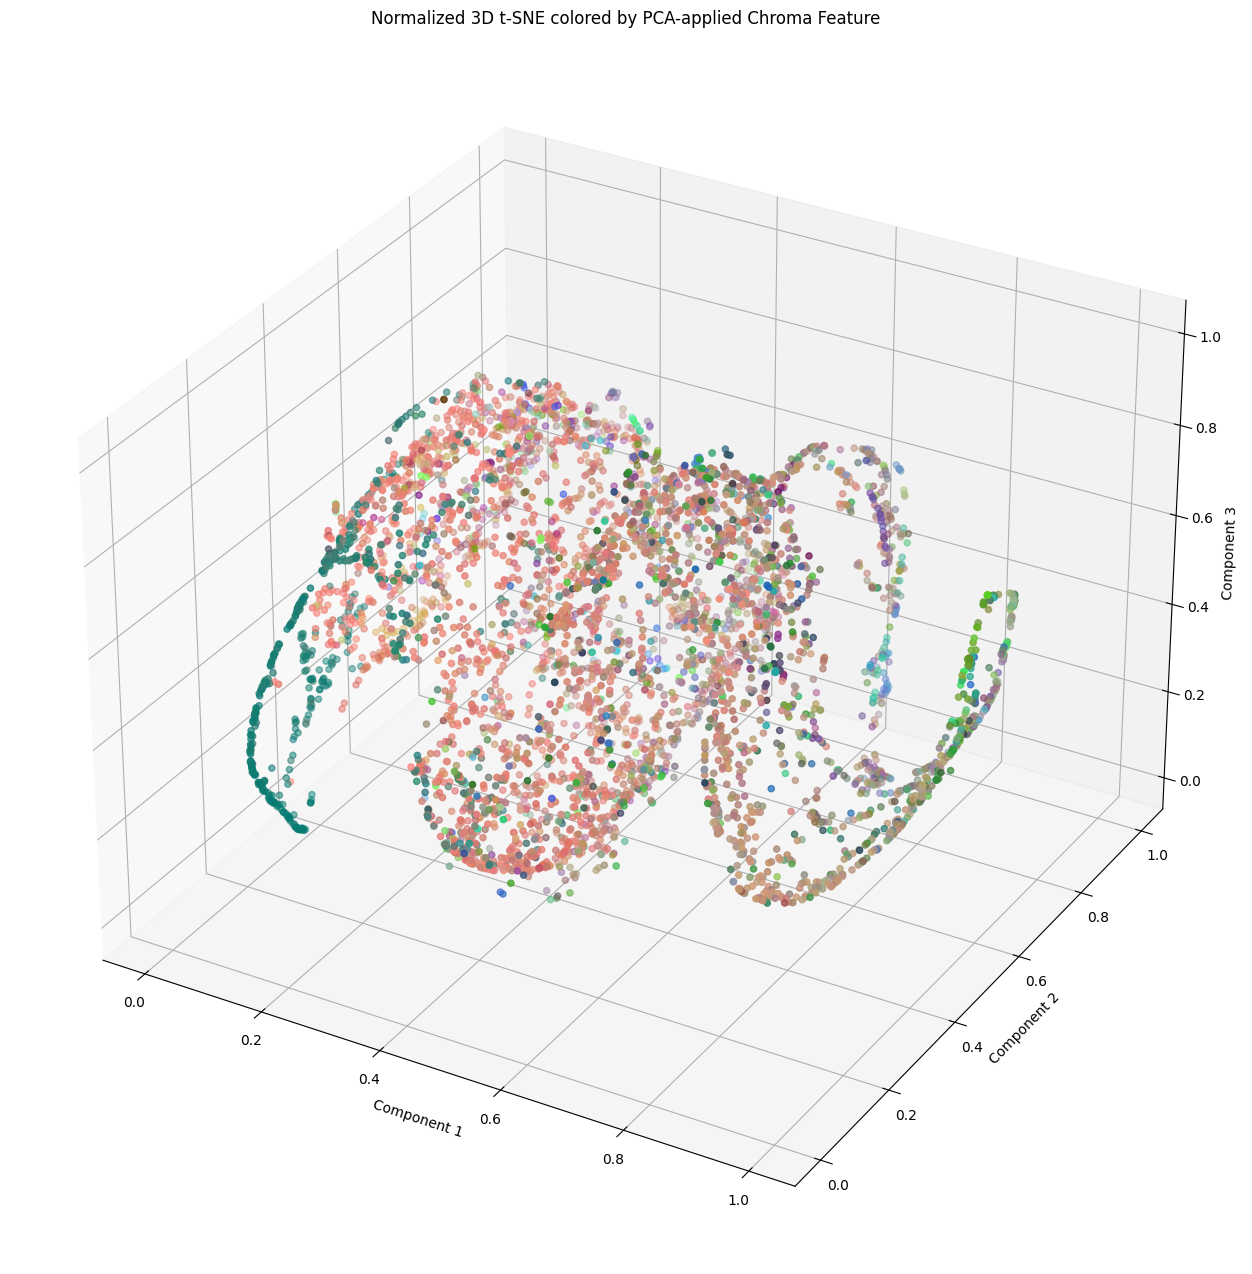

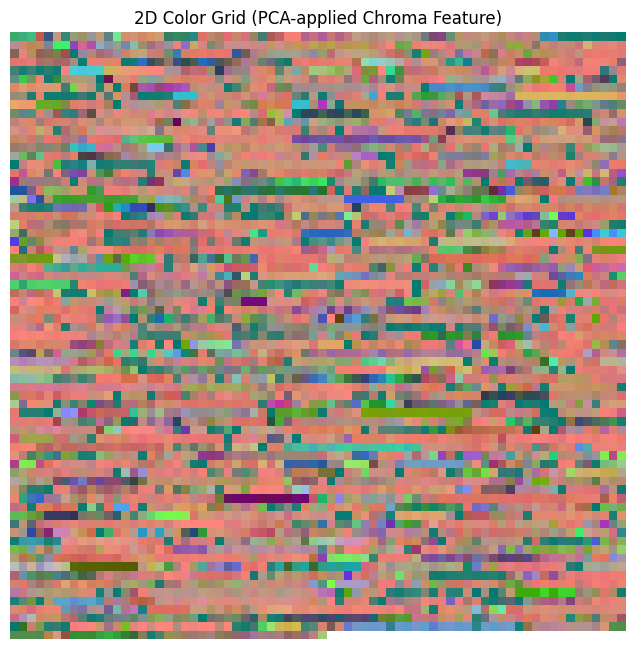

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm  # tqdm 임포트
from sklearn.decomposition import PCA  # 추가: sklearn.decomposition에서 PCA 임포트

try:
    with open(features_pkl_path, 'rb') as f:
        features_list = pickle.load(f)
except FileNotFoundError:
    print(f"File {features_pkl_path} not found.")
    features_list = []

# 리스트에 3가지 오디오 설명자를 결합한 값을 저장
descriptors_list = []

# 3가지 설명자 키 (featureExtractor.py에 정의된 키 사용)
desc_keys = ['mfccs_mean', 'spectral_centroid_mean', 'chroma_mean']

# Extract and combine descriptors for each audio unit
for idx, feature_data in enumerate(tqdm(features_list, desc='Extracting descriptors')):
    combined = []
    valid = True
    for key in desc_keys:
        data = feature_data.get(key)
        if data is None:
            valid = False
            break
        arr = np.array(data)
        # 만약 스칼라(0차원)라면 1차원 배열로 변환
        if arr.ndim == 0:
            arr = np.array([arr])
        # 2D 데이터인 경우 시간축 평균을 취함
        elif arr.ndim == 2:
            arr = np.mean(arr, axis=1)
        elif arr.ndim != 1:
            valid = False
            break
        combined.append(arr)
    if valid and len(combined) == len(desc_keys):
        # Concatenate the descriptors along axis 0
        combined_descriptor = np.concatenate(combined)
        descriptors_list.append(combined_descriptor)
    else:
        print(f"Skipping feature_data index {idx}: missing or invalid descriptors.")

if not descriptors_list:
    print("No valid combined descriptor data found.")
else:
    # 모든 feature vector의 길이가 동일한지 확인 후 필터링
    valid_descriptors = []
    valid_indices = []  # 원본 인덱스 저장 리스트
    target_len = None
    for i, vec in enumerate(descriptors_list):
        vec = np.array(vec)
        if vec.size == 0:
            continue
        if target_len is None:
            target_len = vec.shape[0]
        if vec.shape[0] == target_len:
            valid_descriptors.append(vec)
            valid_indices.append(i)
    if not valid_descriptors:
        print("No valid descriptor data with consistent dimensions.")
    else:
        descriptors_array = np.vstack(valid_descriptors)

        # Perform t-SNE to reduce dimensionality to 3D (진행 상황은 TSNE 객체의 verbose 옵션을 통해 확인 가능)
        tsne = TSNE(n_components=3, random_state=0, verbose=1)
        descriptors_3d = tsne.fit_transform(descriptors_array)

        # Normalize the 3D coordinates to fit in the range 0 to 1
        min_vals = descriptors_3d.min(axis=0)
        max_vals = descriptors_3d.max(axis=0)
        descriptors_3d_normalized = (descriptors_3d - min_vals) / (max_vals - min_vals)

        # ------------------------------------------------------------------
        # 1. 색상 매핑: 크로마 피쳐 (chroma_mean)의 앞 3개 값을 RGB로 사용
        chroma_colors = []
        # valid_indices를 통해 원본 feature_data에 접근
        for i in valid_indices:
            feature_data = features_list[i]
            chroma = np.array(feature_data.get('chroma_mean', []))
            # 크로마의 길이가 3 이상이면 앞 3개 요소로, 그렇지 않으면 0으로 패딩
            if chroma.size >= 3:
                rgb = chroma[:3]
            else:
                rgb = np.pad(chroma, (0, 3 - chroma.size), mode='constant', constant_values=0)
            # 일반적으로 크로마 값은 이미 [0,1] 범위이지만, 혹시 모를 상황에 대비하여 clip
            rgb = np.clip(rgb, 0, 1)
            chroma_colors.append(rgb)
        chroma_colors = np.array(chroma_colors)

        # 3D scatter plot using chroma-based colors
        fig = plt.figure(figsize=(16, 16))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(
            descriptors_3d_normalized[:, 0],
            descriptors_3d_normalized[:, 1],
            descriptors_3d_normalized[:, 2],
            c=chroma_colors,
            marker='o'
        )
        ax.set_title('Normalized 3D t-SNE colored by Chroma Feature (first 3 values)')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.set_zlabel('Component 3')
        plt.show()

        # 2D color grid for chroma-based colors
        grid_size = int(np.ceil(np.sqrt(len(chroma_colors))))
        padded_chroma = np.pad(
            chroma_colors,
            ((0, grid_size**2 - len(chroma_colors)), (0, 0)),
            mode='constant',
            constant_values=1.0
        )
        chroma_grid = padded_chroma.reshape((grid_size, grid_size, 3))
        plt.figure(figsize=(8, 8))
        plt.imshow(chroma_grid)
        plt.title('2D Color Grid (Chroma Feature)')
        plt.axis('off')
        plt.show()

        # ------------------------------------------------------------------
        # 2. 색상 매핑: 스펙트럴 중심값 (spectral_centroid_mean)을 이용한 매핑
        spectral_values = []
        for i in valid_indices:
            feature_data = features_list[i]
            spec = feature_data.get('spectral_centroid_mean', 0.0)
            spectral_values.append(spec)
        spectral_values = np.array(spectral_values)
        # 스펙트럴 중심값 normalize (0~1)
        spec_min, spec_max = spectral_values.min(), spectral_values.max()
        spectral_norm = (spectral_values - spec_min) / (spec_max - spec_min)
        # viridis colormap을 적용하여 RGB 값을 얻음
        cmap = plt.cm.viridis
        spectral_colors = cmap(spectral_norm)[:, :3]

        # 3D scatter plot using spectral centroid based colors
        fig = plt.figure(figsize=(16, 16))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(
            descriptors_3d_normalized[:, 0],
            descriptors_3d_normalized[:, 1],
            descriptors_3d_normalized[:, 2],
            c=spectral_colors,
            marker='o'
        )
        ax.set_title('Normalized 3D t-SNE colored by Spectral Centroid')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.set_zlabel('Component 3')
        plt.show()

        # 2D color grid for spectral centroid based colors
        grid_size = int(np.ceil(np.sqrt(len(spectral_colors))))
        padded_spectral = np.pad(
            spectral_colors,
            ((0, grid_size**2 - len(spectral_colors)), (0, 0)),
            mode='constant',
            constant_values=1.0
        )
        spectral_grid = padded_spectral.reshape((grid_size, grid_size, 3))
        plt.figure(figsize=(8, 8))
        plt.imshow(spectral_grid)
        plt.title('2D Color Grid (Spectral Centroid)')
        plt.axis('off')
        plt.show()

        # ------------------------------------------------------------------
        # 3. 색상 매핑 (PCA 적용한 크로마 벡터)
        # valid_indices를 이용해 각 오디오 유닛의 12차원 크로마 벡터를 수집
        chroma_all = []
        for i in valid_indices:
            feature_data = features_list[i]
            chroma = np.array(feature_data.get('chroma_mean', []))
            # 12차원 크로마 벡터가 아닐 경우 12차원으로 패딩 (혹은 잘라냄)
            if chroma.size < 12:
                chroma = np.pad(chroma, (0, 12 - chroma.size), mode='constant', constant_values=0)
            elif chroma.size > 12:
                chroma = chroma[:12]
            chroma_all.append(chroma)
        chroma_all = np.array(chroma_all)

        # PCA를 적용하여 3차원으로 축소
        pca = PCA(n_components=3)
        chroma_pca = pca.fit_transform(chroma_all)

        # PCA 결과를 0~1 범위로 normalize
        min_vals = chroma_pca.min(axis=0)
        max_vals = chroma_pca.max(axis=0)
        chroma_pca_normalized = (chroma_pca - min_vals) / (max_vals - min_vals)

        # 3D scatter plot: t-SNE 결과에 PCA로 얻은 크로마 색상 적용
        fig = plt.figure(figsize=(16, 16))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(
            descriptors_3d_normalized[:, 0],
            descriptors_3d_normalized[:, 1],
            descriptors_3d_normalized[:, 2],
            c=chroma_pca_normalized,
            marker='o'
        )
        ax.set_title('Normalized 3D t-SNE colored by PCA-applied Chroma Feature')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.set_zlabel('Component 3')
        plt.show()

        # 2D 색상 그리드도 출력 (PCA 색상)
        grid_size = int(np.ceil(np.sqrt(len(chroma_pca_normalized))))
        padded_pca = np.pad(
            chroma_pca_normalized,
            ((0, grid_size**2 - len(chroma_pca_normalized)), (0, 0)),
            mode='constant',
            constant_values=1.0
        )
        pca_grid = padded_pca.reshape((grid_size, grid_size, 3))
        plt.figure(figsize=(8, 8))
        plt.imshow(pca_grid)
        plt.title('2D Color Grid (PCA-applied Chroma Feature)')
        plt.axis('off')
        plt.show()

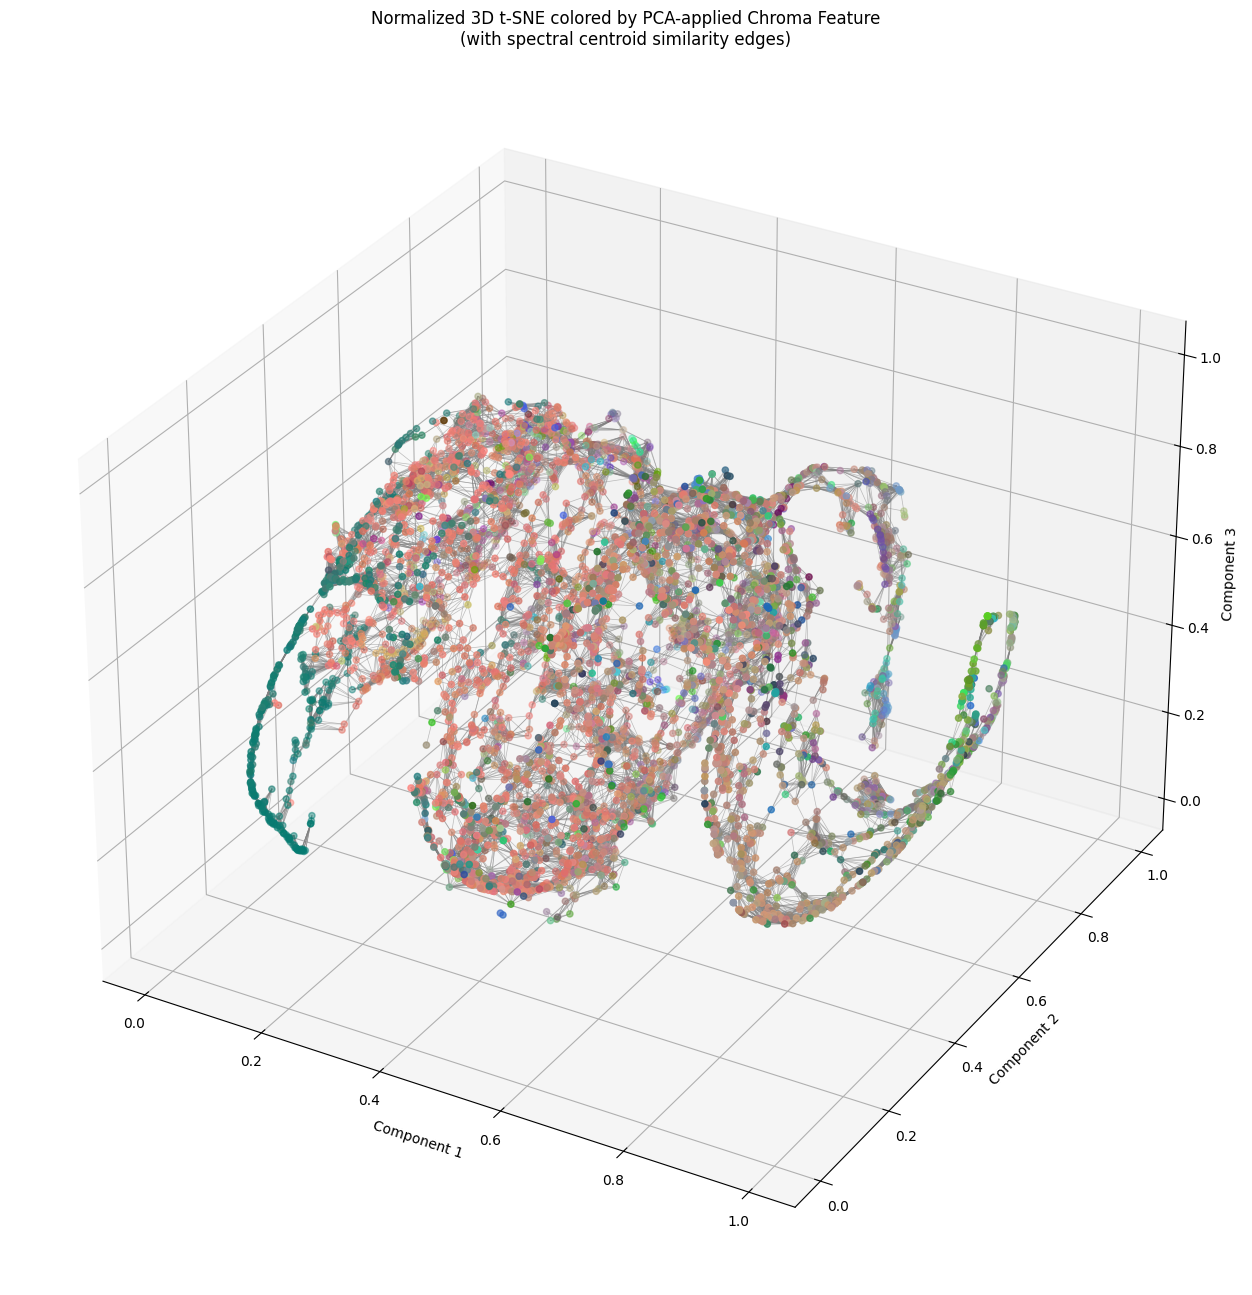

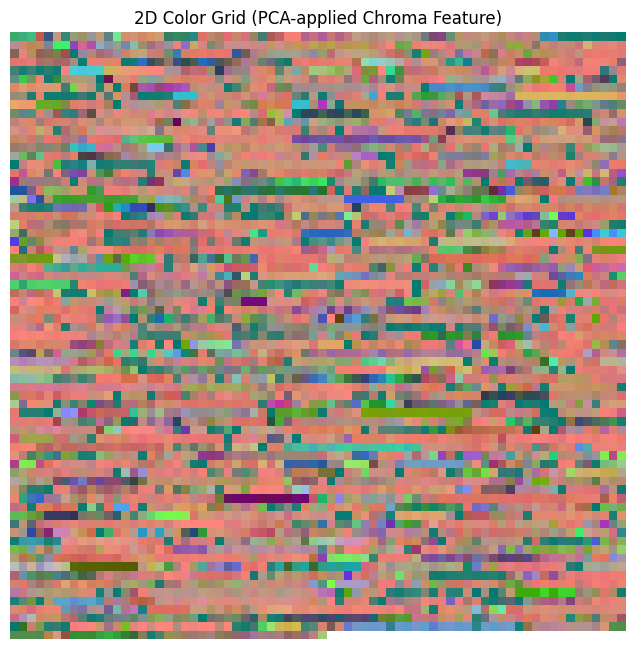

In [9]:
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform

# valid_indices를 이용해 각 오디오 유닛의 12차원 크로마 벡터를 수집
chroma_all = []
for i in valid_indices:
    feature_data = features_list[i]
    chroma = np.array(feature_data.get('chroma_mean', []))
    # 12차원 크로마 벡터가 아닐 경우 12차원으로 패딩하거나 잘라냄
    if chroma.size < 12:
        chroma = np.pad(chroma, (0, 12 - chroma.size), mode='constant', constant_values=0)
    elif chroma.size > 12:
        chroma = chroma[:12]
    chroma_all.append(chroma)
chroma_all = np.array(chroma_all)

# PCA를 적용하여 3차원으로 축소 및 normalize
pca = PCA(n_components=3)
chroma_pca = pca.fit_transform(chroma_all)
min_vals = chroma_pca.min(axis=0)
max_vals = chroma_pca.max(axis=0)
chroma_pca_normalized = (chroma_pca - min_vals) / (max_vals - min_vals)

# 스펙트럴 중심값도 valid_indices로부터 수집 후 normalize (0~1)
spectral_values = []
for i in valid_indices:
    feature_data = features_list[i]
    spec = feature_data.get('spectral_centroid_mean', 0.0)
    spectral_values.append(spec)
spectral_values = np.array(spectral_values)
spec_min, spec_max = spectral_values.min(), spectral_values.max()
spectral_norm = (spectral_values - spec_min) / (spec_max - spec_min)

# 3D scatter plot: t-SNE 결과의 위치에 PCA로 얻은 크로마 색상을 적용
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    descriptors_3d_normalized[:, 0],
    descriptors_3d_normalized[:, 1],
    descriptors_3d_normalized[:, 2],
    c=chroma_pca_normalized,
    marker='o'
)

# 선분 조건: t-SNE 공간상의 유클리드 거리와 스펙트럴 중심 정규화 값 차이가 모두 일정 임계치 이하인 경우
threshold_tsne = 0.05   # t-SNE 좌표 상의 거리 임계치 (0~1 기준)
threshold_spec = 0.1    # 스펙트럴 중심 정규화 값 차이 임계치

# pairwise t-SNE 거리와 스펙트럴 중심 차이 행렬 계산
tsne_dists = squareform(pdist(descriptors_3d_normalized))
spec_diffs = squareform(pdist(spectral_norm.reshape(-1, 1), metric='cityblock'))

# 두 조건을 만족하는 인덱스 쌍 검색 (중복 제거를 위해 i < j)
pairs = np.where((tsne_dists < threshold_tsne) & (spec_diffs < threshold_spec))
for i, j in zip(pairs[0], pairs[1]):
    if i < j:
        xs = [descriptors_3d_normalized[i, 0], descriptors_3d_normalized[j, 0]]
        ys = [descriptors_3d_normalized[i, 1], descriptors_3d_normalized[j, 1]]
        zs = [descriptors_3d_normalized[i, 2], descriptors_3d_normalized[j, 2]]
        ax.plot(xs, ys, zs, c='gray', alpha=0.5, linewidth=0.5)

ax.set_title('Normalized 3D t-SNE colored by PCA-applied Chroma Feature\n(with spectral centroid similarity edges)')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
plt.show()

# 2D 색상 그리드 (PCA 적용 크로마 색상)
grid_size = int(np.ceil(np.sqrt(len(chroma_pca_normalized))))
padded_pca = np.pad(
    chroma_pca_normalized,
    ((0, grid_size**2 - len(chroma_pca_normalized)), (0, 0)),
    mode='constant',
    constant_values=1.0
)
pca_grid = padded_pca.reshape((grid_size, grid_size, 3))
plt.figure(figsize=(8, 8))
plt.imshow(pca_grid)
plt.title('2D Color Grid (PCA-applied Chroma Feature)')
plt.axis('off')
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import umap.umap_ as umap
from sklearn.cluster import KMeans

# Constants
SAMPLE_SIZE = int(2**10)  # Sample size for faster processing
CLUSTER_COUNT = 10  # Number of clusters for K-means clustering

def load_features(pickle_path):
    """Load feature data from a pickle file."""
    try:
        with open(pickle_path, 'rb') as f:
            features_list = pickle.load(f)
        return features_list
    except FileNotFoundError:
        print(f"File {pickle_path} not found.")
        return []
    except pickle.UnpicklingError:
        print(f"Error unpickling file {pickle_path}.")
        return []

def extract_mfccs(features_list):
    """Extract MFCC values from the feature list."""
    mfccs_list = []
    
    for feature_data in features_list:
        mfccs_mean = feature_data.get('mfccs_mean')
        
        if mfccs_mean is not None:
            mfccs_mean = np.array(mfccs_mean)
            
            if mfccs_mean.ndim == 1:
                mfccs_list.append(mfccs_mean)
            elif mfccs_mean.ndim == 2:
                mfccs_list.append(np.mean(mfccs_mean, axis=1))
    
    return mfccs_list

def process_mfccs(mfccs_list):
    """Process the MFCC list and perform UMAP."""
    mfccs_array = np.array(mfccs_list)
    
    if len(mfccs_array) > SAMPLE_SIZE:
        mfccs_array = mfccs_array[np.random.choice(mfccs_array.shape[0], SAMPLE_SIZE, replace=False)]
    
    umap_model = umap.UMAP(n_components=3, random_state=0)
    mfccs_3d = umap_model.fit_transform(mfccs_array)
    
    return mfccs_3d

def visualize_mfccs(mfccs_3d, labels=None):
    """Visualize the MFCC data in 3D with clustering."""
    min_vals = mfccs_3d.min(axis=0)
    max_vals = mfccs_3d.max(axis=0)
    
    mfccs_3d_normalized = (mfccs_3d - min_vals) / (max_vals - min_vals)
    
    fig = plt.figure(figsize=(16, 16))
    ax = fig.add_subplot(111, projection='3d')
    
    if labels is not None:
        scatter = ax.scatter(mfccs_3d_normalized[:, 0], mfccs_3d_normalized[:, 1], mfccs_3d_normalized[:, 2], 
                             c=labels, cmap='viridis', marker='o')
        fig.colorbar(scatter, ax=ax)
    else:
        ax.scatter(*mfccs_3d_normalized.T)
    
    ax.set_title('Normalized 3D UMAP of MFCCs with Clustering')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    
    plt.show()

def main():
    pickle_path = 'FSDKaggle2018.audio_train_20240812-151810features_.pkl'
    
    features_list = load_features(pickle_path)
    mfccs_list = extract_mfccs(features_list)
    
    if not mfccs_list:
        print("No valid MFCC data found.")
        return
    
    mfccs_3d = process_mfccs(mfccs_list)
    
    kmeans = KMeans(n_clusters=CLUSTER_COUNT, random_state=0)
    labels = kmeans.fit_predict(mfccs_3d)
    
    visualize_mfccs(mfccs_3d, labels)

if __name__ == '__main__':
    main()


ModuleNotFoundError: No module named 'umap'